In [26]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

In [27]:
# Load and prepare data
def load_and_preprocess(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    rows = []
    label_mapping = {"yes": 1, "no": 0, "maybe": 2}

    for pmid, item in data.items():
        question = item["QUESTION"]
        contexts = " ".join(item["CONTEXTS"])

        rows.append({
            "pmid": pmid,
            "question": question,
            "contexts": contexts,
            "text": f"{question} {contexts}",
            "label": item["final_decision"]
        })

    return pd.DataFrame(rows)

pqal_path = f"data/ori_pqal.json"
proc_data = load_and_preprocess(pqal_path)

# Context and question length

In [28]:
# Context and question length
context_list = [len(proc_data['contexts'][x]) for x in range(len(proc_data))]
context_dict = {'mean length': int(np.mean(context_list)), 'std': int(np.std(context_list)), 'max': int(np.max(context_list)), 'min': int(np.min(context_list))}
print('Context:', context_dict)
question_list = [len(proc_data['question'][x]) for x in range(len(proc_data))]
question_dict = {'mean length': int(np.mean(question_list)), 'std': int(np.std(question_list)), 'max': int(np.max(question_list)), 'min': int(np.min(question_list))}
print('Question:', question_dict)

Context: {'mean length': 1341, 'std': 344, 'max': 2725, 'min': 293}
Question: {'mean length': 94, 'std': 29, 'max': 213, 'min': 22}


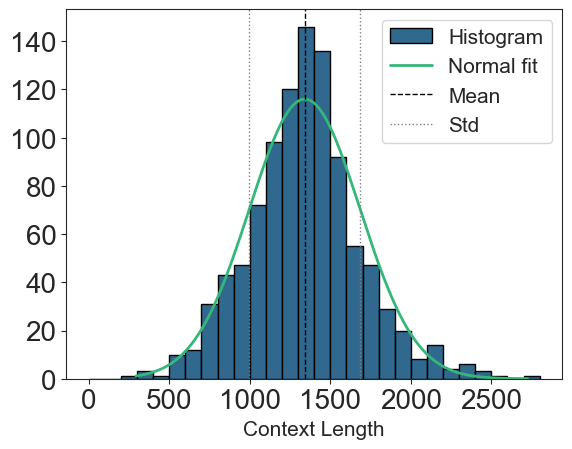

In [29]:
# Context length histogram

# Bin settings
bin_width = 100
bins = np.arange(0, context_dict['max'] + bin_width, bin_width)

# Colours and style
colours = sns.color_palette("viridis", n_colors=2)
sns.set_style("ticks")

# Histogram
plt.figure()
count, bins, _ = plt.hist(context_list, bins=bins, color=colours[0], edgecolor='black', label='Histogram')

# Normal distribution curve
N = len(context_list)
mu, sigma = context_dict['mean length'], context_dict['std']
x = np.linspace(min(context_list), max(context_list), 1000)
plt.plot(x, norm.pdf(x, mu, sigma) * N * bin_width, color=colours[1], linewidth=2, label='Normal fit')

# Mean & standard deviation
plt.axvline(mu, color='black', linestyle='--', linewidth=1, label='Mean')
plt.axvline(mu + sigma, color='gray', linestyle=':', linewidth=1, label='Std')
plt.axvline(mu - sigma, color='gray', linestyle=':', linewidth=1)

# Labels and title
plt.xlabel('Context Length', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=15)

plt.show()

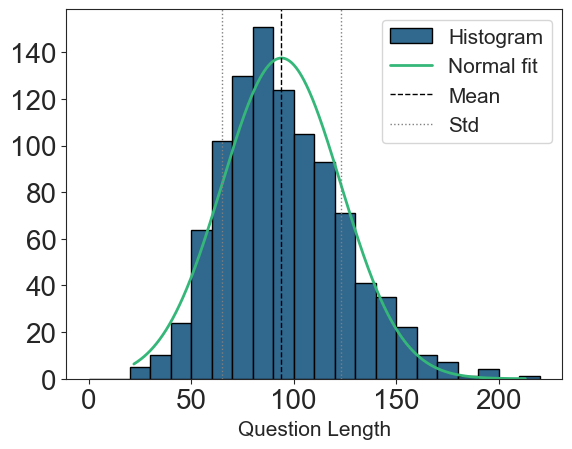

In [30]:
# Question length histogram

# Bin settings
bin_width = 10
bins = np.arange(0, question_dict['max'] + bin_width, bin_width)

# Colours and style
colours = sns.color_palette("viridis", n_colors=2)
sns.set_style("ticks")

# Histogram
plt.figure()
count, bins, _ = plt.hist(question_list, bins=bins, color=colours[0], edgecolor='black', label='Histogram')

# Normal distribution curve
N = len(question_list)
mu, sigma = question_dict['mean length'], question_dict['std']
x = np.linspace(min(question_list), max(question_list), 1000)
plt.plot(x, norm.pdf(x, mu, sigma) * N * bin_width, color=colours[1], linewidth=2, label='Normal fit')

# Mean & standard deviation
plt.axvline(mu, color='black', linestyle='--', linewidth=1, label='Mean')
plt.axvline(mu + sigma, color='gray', linestyle=':', linewidth=1, label='Std')
plt.axvline(mu - sigma, color='gray', linestyle=':', linewidth=1)

# Labels and title
plt.xlabel('Question Length', fontsize=15)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=15)

plt.show()

# Label distribution

In [31]:
# Label counts
label_list = [proc_data['label'][x] for x in range(len(proc_data))]
counts = np.unique(label_list, return_counts=True)
counts_dict = {str(counts[0][x]):float(counts[1][x]) for x in range(len(counts[0]))}

# Reverse order
counts_sorted = dict(sorted(counts_dict.items(), key=lambda item: item[1], reverse=True))

# Label proportions
sum_counts = len(proc_data)
dict_perc = {label:(value/sum_counts) for label, value in counts_sorted.items()}
print(dict_perc)

print(counts_sorted.keys())

{'yes': 0.552, 'no': 0.338, 'maybe': 0.11}
dict_keys(['yes', 'no', 'maybe'])


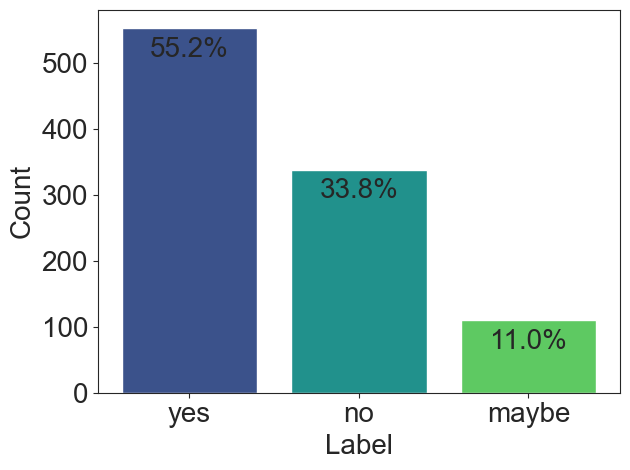

In [32]:
# Proportion list for labels
props = [f"{value*100:.1f}%" for value in dict_perc.values()]

# Colours and style
colours = sns.color_palette("viridis", n_colors=3)
sns.set_style("ticks")

# Bar chart
fig, ax = plt.subplots()
bar = ax.bar(counts_sorted.keys(), counts_sorted.values(), color=colours)
ax.bar_label(bar, labels=props, fontsize=20, padding=-25)

# Labels
plt.xlabel('Label', fontsize=20)
plt.ylabel('Count', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.tight_layout()
plt.show()